In [35]:
from sts.quant.indicators import trend, consolidate, breakout
from sts.dio.equity import Ticker
from sts.dio.symbols import sp500_symbol_table
from sts.plots.time_series_plots import plot_multi_time_series
from sts.plots.candle import candle_plot
from scipy.signal import find_peaks
import pandas as pd
import datetime as dt
import numpy as np

# Functions

In [5]:
def get_peak_valley_info(ts: pd.Series) -> list:
    peak_properties = dict(width=5, height=0.5, distance=5)
    peak_list, _ = find_peaks(ts, **peak_properties)
    # find the valley bettwen peaks
    peak_valley_result = [(peak_list[0], "Peak", ts.iloc[peak_list[0]])]
    for n in range(1, len(peak_list)):
        peak1, peak2 = peak_list[n - 1], peak_list[n]
        valley = peak1
        for m in range(peak1, peak2):
            if ts.iloc[valley] >= ts.iloc[m]:
                valley = m
        peak_valley_result.append((valley, "Valley", ts.iloc[valley]))
        peak_valley_result.append((peak2, "Peak", ts.iloc[peak2]))

    return peak_valley_result


def get_peak_info(df: pd.DataFrame, rolling_window: int = 20) -> pd.DataFrame:
    trend_score_ts = trend.get_trend_score(df, rolling_window)
    peak_valley_info = get_peak_valley_info(trend_score_ts)
    peak_valley_df = pd.DataFrame(
        [(df.iloc[v[0]].name, v[1], df.iloc[v[0]]["Close"]) for v in peak_valley_info],
        columns=["Date", "PeakValley", "Close"],
    )
    peak_valley_df["chg"] = peak_valley_df["Close"].diff(periods=1) / peak_valley_df["Close"].shift(periods=1)
    return peak_valley_df

# Setup Detect

## Stock Surge

In [6]:
firm_info = pd.read_csv("/home/yuqing42/projects/systrading/data/nasdaq_screener_1730166792910.csv")

In [9]:
period = "2y"
surge_threshold = 0.30
days = 66
market_cap_threshold = 20e9
today_date = dt.date.today()
surge_stock_store_path_format = "/home/yuqing42/projects/systrading/data/Equity/surge_stock_{date:s}.pkl"

In [ ]:
all_peak_df = None
for sym in sp500_symbol_table.to_symbol():
    print(sym, end=", ")
    ticker = Ticker(sym.YahooSym)
    try:
        df = ticker.history(period=period)
        peak_df = get_peak_info(df)
        peak_df = peak_df[peak_df["chg"] >= surge_threshold].copy()
        peak_df["sym"] = sym.YahooSym
        if len(peak_df) > 0:
            print("")
            print(peak_df.iloc[-1:])
            all_peak_df = pd.concat([all_peak_df, peak_df.iloc[-1:]])
    except Exception as e:
        print(e)

all_peak_df["Today"] = today_date
all_peak_df["days"] = (pd.to_datetime(all_peak_df["Today"]) - all_peak_df["Date"]).dt.days
all_peak_df = all_peak_df.merge(
    firm_info[["Symbol", "Name", "Market Cap", "IPO Year", "Sector", "Industry"]].rename(columns={"Symbol": "sym"}),
    on="sym",
    how="left",
)
all_peak_df.to_pickle(surge_stock_store_path_format.format(date=today_date.strftime("%Y%m%d")))

MMM, 
        Date PeakValley       Close      chg  sym
4 2024-08-30       Peak  134.690002  0.30976  MMM
AOS, ABT, ABBV, ACN, ATVI, 

ATVI: No data found, symbol may be delisted


'Index' object has no attribute 'tz_localize'
ADM, ADBE, ADP, AAP, AES, AFL, A, APD, AKAM, ALK, 
        Date PeakValley  Close       chg  sym
2 2024-04-29       Peak  44.09  0.418597  ALK
ALB, index 0 is out of bounds for axis 0 with size 0
ARE, ALGN, 
        Date PeakValley       Close       chg   sym
2 2024-03-28       Peak  327.920013  0.714883  ALGN
ALLE, 
        Date PeakValley       Close       chg   sym
8 2024-10-22       Peak  150.600006  0.317734  ALLE
LNT, ALL, GOOGL, GOOG, MO, AMZN, AMCR, AMD, 
        Date PeakValley       Close       chg  sym
4 2024-01-29       Peak  177.830002  0.813297  AMD
AEE, AAL, AEP, AXP, AIG, AMT, 
        Date PeakValley       Close       chg  sym
2 2024-08-12       Peak  223.910889  0.325555  AMT
AWK, AMP, ABC, 

ABC: No data found, symbol may be delisted


'Index' object has no attribute 'tz_localize'
AME, AMGN, APH, ADI, ANSS, AON, APA, AAPL, 
        Date PeakValley       Close       chg   sym
4 2024-07-16       Peak  234.548523  0.401469  AAPL
AMAT, 
        Date PeakValley       Close       chg   sym
6 2024-03-07       Peak  211.817154  0.388605  AMAT
APTV, index 0 is out of bounds for axis 0 with size 0
ACGL, ANET, 
        Date PeakValley       Close       chg   sym
2 2023-09-08       Peak  196.470001  0.391234  ANET
AJG, AIZ, T, ATO, ADSK, 
        Date PeakValley       Close       chg   sym
2 2024-10-30       Peak  288.820007  0.349942  ADSK
AZO, 
        Date PeakValley        Close       chg  sym
2 2024-03-27       Peak  3192.790039  0.330651  AZO
AVB, AVY, AXON, 
        Date PeakValley       Close       chg   sym
2 2023-12-29       Peak  258.329987  0.470039  AXON
BKR, 
        Date PeakValley      Close       chg  sym
4 2024-08-01       Peak  37.420895  0.313666  BKR
BALL, BAC, BBWI, BAX, BDX, WRB, BRK.B, 

...

'Index' object has no attribute 'tz_localize'
HSIC, index 0 is out of bounds for axis 0 with size 0
HSY, HES, HPE, 
        Date PeakValley      Close       chg  sym
2 2024-07-02       Peak  20.969969  0.440307  HPE
HLT, HOLX, HD, HON, HRL, HST, HWM, 
        Date PeakValley      Close       chg  sym
6 2024-05-30       Peak  84.156731  0.300644  HWM
HPQ, 
        Date PeakValley      Close       chg  sym
2 2024-06-25       Peak  35.970913  0.426985  HPQ
HUM, index 0 is out of bounds for axis 0 with size 0
HBAN, HII, IBM, 
         Date PeakValley       Close       chg  sym
10 2024-10-17       Peak  232.880005  0.390287  IBM
IEX, IDXX, 
        Date PeakValley       Close       chg   sym
2 2023-12-29       Peak  555.049988  0.403946  IDXX
ITW, ILMN, index 0 is out of bounds for axis 0 with size 0
INCY, IR, 
        Date PeakValley      Close       chg sym
6 2024-03-04       Peak  91.479546  0.508999  IR
PODD, INTC, 
        Date PeakValley      Close       chg   sym
2 2023-12-29       P

PXD: No data found, symbol may be delisted


'Index' object has no attribute 'tz_localize'
PNC, POOL, PPG, PPL, PFG, PG, PGR, 
        Date PeakValley       Close       chg  sym
4 2024-04-03       Peak  210.587372  0.330555  PGR
PLD, PRU, PEG, PTC, PSA, 
        Date PeakValley      Close       chg  sym
2 2024-09-24       Peak  361.98999  0.418685  PSA
PHM, 
        Date PeakValley       Close       chg  sym
6 2023-12-29       Peak  102.712349  0.456235  PHM
QRVO, PWR, 
        Date PeakValley       Close       chg  sym
4 2023-12-29       Peak  215.649796  0.352523  PWR
QCOM, 
        Date PeakValley      Close       chg   sym
6 2024-06-18       Peak  225.92247  0.389438  QCOM
DGX, RL, 
        Date PeakValley       Close       chg sym
4 2024-03-01       Peak  182.601654  0.304124  RL
RJF, RTX, O, REG, 
        Date PeakValley      Close       chg  sym
4 2024-09-16       Peak  74.769997  0.320857  REG
REGN, RF, RSG, RMD, 
        Date PeakValley       Close       chg  sym
6 2024-09-17       Peak  250.880005  0.307543  RMD
RVTY, i

WRK: No data found, symbol may be delisted


'Index' object has no attribute 'tz_localize'
WY, WHR, WMB, WTW, GWW, WYNN, 
        Date PeakValley       Close       chg   sym
2 2024-10-14       Peak  103.949997  0.408587  WYNN
XEL, 

In [14]:
all_peak_df = pd.read_pickle(surge_stock_store_path_format.format(date=today_date.strftime("%Y%m%d")))
valid_peak_df = all_peak_df[
    (all_peak_df["days"] <= days) & (all_peak_df["Market Cap"] >= market_cap_threshold)
].sort_values("Date", ascending=False)

In [26]:
valid_peak_df

,Date,PeakValley,Close,chg,sym,Today,days,Name,Market Cap,IPO Year,Sector,Industry
9,2024-10-30,Peak,288.820007,0.349942,ADSK,2024-11-04,5,Autodesk Inc. Common Stock,6.160180e+10,NaN,Technology,Computer Software: Prepackaged Software
107,2024-10-22,Peak,847.460022,0.363362,URI,2024-11-04,13,United Rentals Inc. Common Stock,5.411549e+10,1997.0,Consumer Discretionary,Diversified Commercial Services
53,2024-10-17,Peak,232.880005,0.390287,IBM,2024-11-04,18,International Business Machines Corporation Co...,1.961217e+11,NaN,Technology,Computer Manufacturing
24,2024-10-16,Peak,279.799988,0.560287,CEG,2024-11-04,19,Constellation Energy Corporation Common Stock,8.348173e+10,NaN,Utilities,Electric Utilities: Central
83,2024-10-14,Peak,176.119995,0.314733,ORCL,2024-11-04,21,Oracle Corporation Common Stock,4.777703e+11,1986.0,Technology,Computer Software: Prepackaged Software
81,2024-10-02,Peak,9732.629883,0.300444,NVR,2024-11-04,33,NVR Inc. Common Stock,2.864562e+10,1998.0,Consumer Discretionary,Homebuilding
87,2024-09-24,Peak,361.989990,0.418685,PSA,2024-11-04,41,Public Storage Common Stock,5.891295e+10,NaN,Real Estate,Real Estate Investment Trusts
96,2024-09-24,Peak,923.599976,0.321675,NOW,2024-11-04,41,ServiceNow Inc. Common Stock,1.946700e+11,2012.0,Technology,Computer Software: Prepackaged Software
93,2024-09-17,Peak,250.880005,0.307543,RMD,2024-11-04,48,ResMed Inc. Common Stock,3.626725e+10,NaN,Health Care,Medical/Dental Instruments
111,2024-09-13,Peak,65.059998,0.550625,VTR,2024-11-04,52,Ventas Inc. Common Stock,2.674758e+10,NaN,Real Estate,Real Estate Investment Trusts


we should exclude any stock with mkt cap less than 10b since that is supper volatile

## Consolidation

An orderly pullback in price action refers to a temporary, controlled decline in an asset's price that occurs within an overall uptrend. Here are the key characteristics of an orderly pullback:
* Gradual price decline: The price moves lower in a steady, measured manner without sharp drops or volatile swings.
* Lower volume: Trading volume during the pullback is typically lower than during the preceding uptrend23.
* Short duration: An orderly pullback usually lasts only a few consecutive sessions before the uptrend resumes2.
* Consistent price action: The intraday trading range of each day during the pullback should be about the same1.
* Support levels: The price often pulls back to a key support level, such as a moving average (e.g., 20-day EMA or 50-day MA)1.
* Absence of negative news: There's typically no significant negative news or fundamental changes driving the pullback2.
* Buying opportunity: Traders often view orderly pullbacks as low-risk entry points to buy into an uptrending stock12.
* Maintained uptrend structure: The pullback doesn't violate the overall uptrend structure, typically maintaining higher lows compared to previous significant price swings.
* Technical indicators: Other technical indicators often remain bullish during an orderly pullback2.
* Reversal signs: The pullback may end with bullish reversal candlestick patterns, signaling the potential resumption of the uptrend1.

In [62]:
peak_within_days = [66, 5]
market_cap_threshold = 20e9
today_date = dt.date.today()
surge_stock_store_path_format = "/home/yuqing42/projects/systrading/data/Equity/surge_stock_{date:s}.pkl"
all_peak_df = pd.read_pickle(surge_stock_store_path_format.format(date=today_date.strftime("%Y%m%d")))
all_peak_df["Today"] = today_date
all_peak_df["days"] = (pd.to_datetime(all_peak_df["Today"]) - all_peak_df["Date"]).dt.days
valid_surge_df = all_peak_df[
    (all_peak_df["days"] <= peak_within_days[0])
    & (all_peak_df["days"] >= peak_within_days[1])
    & (all_peak_df["Market Cap"] >= market_cap_threshold)
].sort_values("Date", ascending=False)

In [63]:
for index, row in valid_surge_df.iterrows():
    break

In [76]:
ticker = Ticker(row["sym"])

In [77]:
ticker

yfinance.Ticker object <ADSK>

In [78]:
df = ticker.history(period="10y")

In [79]:
peak_info = get_peak_info(df)

In [80]:
peak_info

,Date,PeakValley,Close,chg
0,2015-12-04,Peak,65.290001,NaN
1,2016-02-16,Valley,44.889999,-0.312452
2,2016-10-06,Peak,72.830002,0.622410
3,2016-11-04,Valley,69.440002,-0.046547
4,2016-11-25,Peak,75.830002,0.092022
5,2016-12-05,Valley,71.180000,-0.061321
6,2016-12-13,Peak,79.669998,0.119275
7,2017-01-03,Valley,76.180000,-0.043806
8,2017-03-01,Peak,88.930000,0.167367
9,2017-04-17,Valley,85.989998,-0.033060


In [81]:
trend_score = trend.get_trend_score(df, 20)

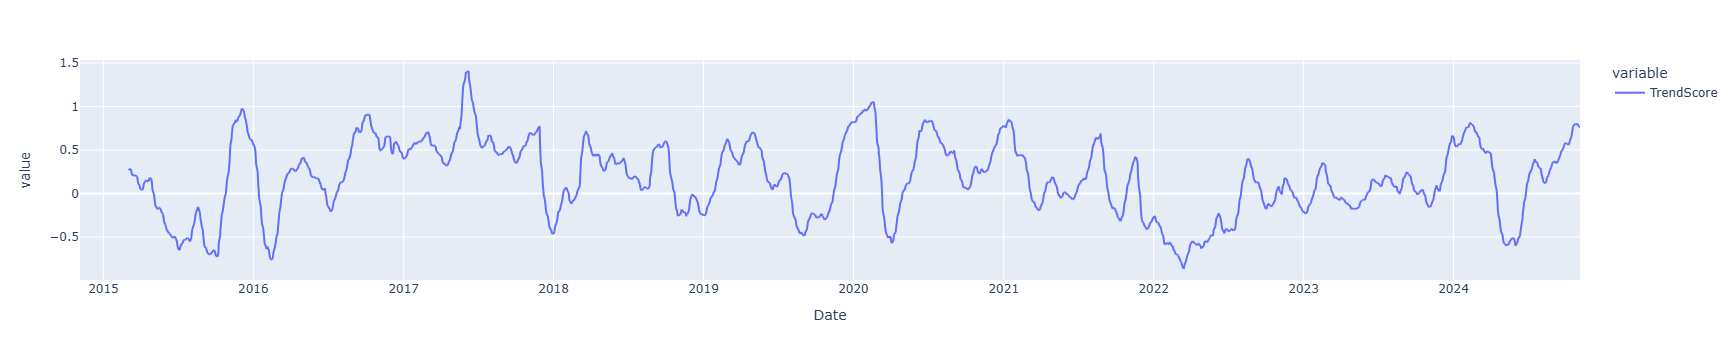

In [82]:
trend_score.plot()

# Questions 

* peak identification is not good enough, 2024.03.28 and 2024.03.04, are too close, need some other critieria to find the peak
* looks the cycle can be obtained from trend_score. And this time scale if stable, we should use it as the strategy horizon indicator
* looks we can also use trend pull back to around 0 as one of the consolidate area


In [22]:
row

Date                       2024-10-22 00:00:00
PeakValley                                Peak
Close                               847.460022
chg                                   0.363362
sym                                        URI
Today                               2024-11-02
days                                        11
Name          United Rentals Inc. Common Stock
Market Cap                       54115494842.0
IPO Year                                1997.0
Sector                  Consumer Discretionary
Industry       Diversified Commercial Services
Name: 108, dtype: object

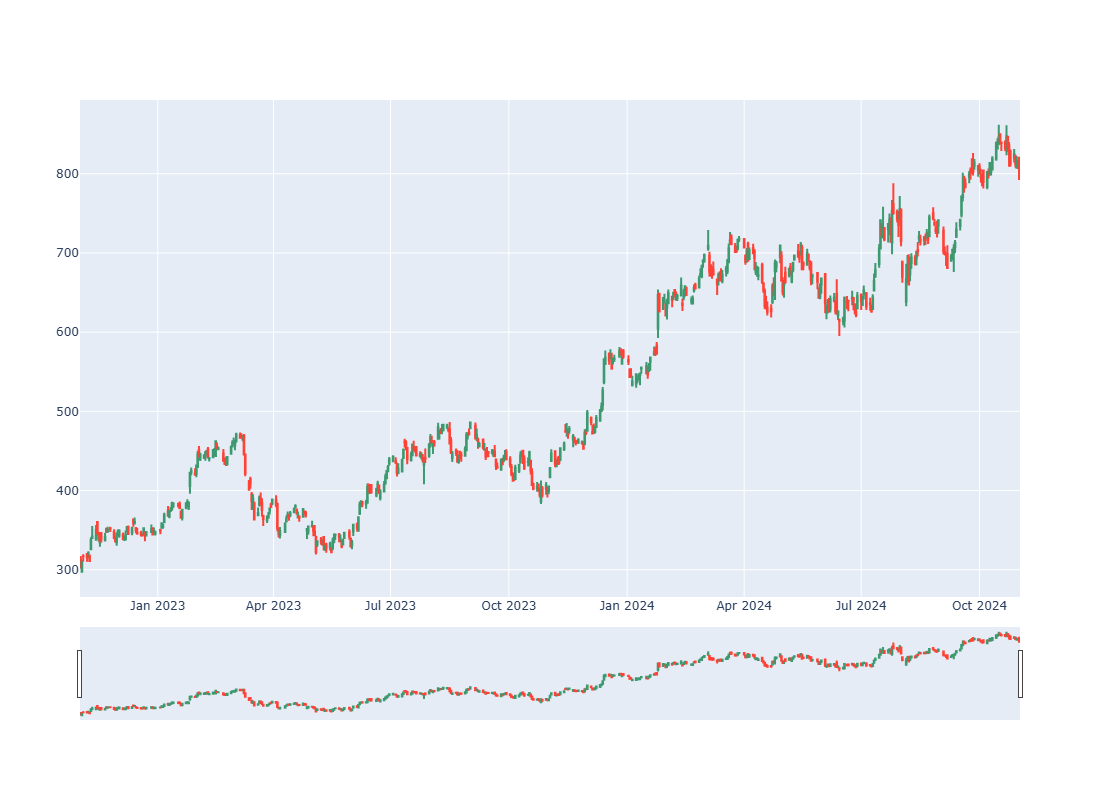

In [34]:
fig = candle_plot(df)
fig.update_layout(width=800, height=800)

## Breakout Again